# Partie 6 - Tracking Intelligent
## Smart Urban Vision - Sup de Vinci M2

**Responsable :** Personne C (Colin)  
**Objectif :** Suivre les objets dans le temps avec des identifiants persistants (ByteTrack).
Passer de la détection frame par frame à une analyse dynamique avec trajectoires.

**Prérequis :** Exécuter le notebook `05_video.ipynb` en premier.  
Ce notebook suppose que `data/videos/urban_sample.mp4` est disponible.

**Livrables produits par ce notebook :**
- `outputs/video/tracking_demo.mp4`
- `outputs/video/tracking_stats.json`

> Exécuter sur **Google Colab** avec GPU T4 activé.

In [1]:
# A exécuter si la session Colab a été relancée depuis le notebook 05
# Si vous continuez directement depuis 05_video, passer cette cellule

!pip install ultralytics -q

from google.colab import drive
drive.mount('/content/drive')

import os
import torch

VIDEO_CLIP   = 'data/videos/urban_sample.mp4'
DRIVE_OUTPUT = '/content/drive/MyDrive/Smart-Urban-Vision-Assets/videos'

os.makedirs('data/videos', exist_ok=True)
os.makedirs('outputs/video', exist_ok=True)

# Si la vidéo n'est plus là (session expirée), on la récupère depuis Drive
if not os.path.exists(VIDEO_CLIP): #@cupxo_oxcake  Nikeza_mgz
    drive_video = DRIVE_OUTPUT + '/annotated_video.mp4'
    if os.path.exists(drive_video):
        print('Vidéo récupérée depuis Drive')
    else:
        print('ATTENTION : relancer la cellule de téléchargement dans 05_video.ipynb')
else:
    print('Vidéo source disponible :', VIDEO_CLIP)

print('GPU :', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 47.2 MB/s eta 0:00:00
Mounted at /content/drive
Vidéo récupérée depuis Drive
GPU : Tesla T4


## Cellule 1 - Tracking avec ByteTrack

In [3]:
import os, shutil

os.makedirs('data/videos', exist_ok=True)
os.makedirs('outputs/video', exist_ok=True)

# Récupération de la vidéo source depuis Drive
# C'est le clip de 30 secondes généré par le notebook 05
src = '/content/drive/MyDrive/Smart-Urban-Vision-Assets/videos/annotated_video.mp4'
dst = 'data/videos/urban_sample.mp4'

# On utilise la vidéo originale si elle a été sauvegardée, sinon la annotée
# Les deux conviennent pour le tracking
if os.path.exists(src):
    shutil.copy(src, dst)
    print('Vidéo récupérée depuis Drive :', dst)
else:
    print('ERREUR : vidéo introuvable sur Drive')
    print('Relancer le notebook 05 pour la régénérer')

Vidéo récupérée depuis Drive : data/videos/urban_sample.mp4


In [4]:
from ultralytics import YOLO
import cv2
import numpy as np
import time
import os

VIDEO_CLIP    = 'data/videos/urban_sample.mp4'
TRACKING_OUT  = 'outputs/video/tracking_demo.mp4'

# Classes urbaines filtrées (identiques au notebook 05)
URBAN_CLASSES = [0, 1, 2, 3, 5, 7, 9, 11, 13, 24, 25, 26, 56, 60, 62, 63, 67, 72, 73]

model = YOLO('yolo11n.pt')

cap    = cv2.VideoCapture(VIDEO_CLIP)
fps_s  = cap.get(cv2.CAP_PROP_FPS)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()

print(f'Source : {width}x{height} à {fps_s} FPS, {total} frames')
print('Lancement du tracking ByteTrack...')

# Exécution du tracking
# ByteTrack est intégré dans ultralytics, pas besoin d'install séparée
results = model.track(
    source=VIDEO_CLIP,
    tracker='bytetrack.yaml',
    conf=0.4,
    classes=URBAN_CLASSES,
    save=False,       # on gère la sortie manuellement ci-dessous
    stream=True,      # mode streaming pour ne pas tout charger en RAM
    verbose=False
)

# Collecte des résultats et écriture de la vidéo annotée
cap_out = cv2.VideoCapture(VIDEO_CLIP)
writer  = cv2.VideoWriter(
    TRACKING_OUT,
    cv2.VideoWriter_fourcc(*'mp4v'),
    fps_s,
    (width, height)
)

# Données de tracking accumulées
track_data   = {}   # track_id -> {class_name, frames, first_frame, last_frame}
frame_idx    = 0
fps_values   = []

# Palette de couleurs pour les IDs (reproductible)
np.random.seed(42)
PALETTE = np.random.randint(50, 255, size=(500, 3), dtype=np.uint8)

for r in results:
    t0 = time.time()

    # Frame annotée de base par ultralytics
    frame = r.orig_img.copy()

    if r.boxes.id is not None:
        ids    = r.boxes.id.int().cpu().numpy()
        clss   = r.boxes.cls.int().cpu().numpy()
        confs  = r.boxes.conf.cpu().numpy()
        bboxes = r.boxes.xyxy.cpu().numpy().astype(int)

        for tid, cls_id, conf, bbox in zip(ids, clss, confs, bboxes):
            tid      = int(tid)
            cls_name = model.names[cls_id]
            color    = tuple(int(c) for c in PALETTE[tid % 500])

            x1, y1, x2, y2 = bbox

            # Bounding box colorée selon l'ID
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

            # Label avec ID et classe
            label = f'ID{tid} {cls_name} {conf:.2f}'
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 1)
            cv2.rectangle(frame, (x1, y1 - th - 8), (x1 + tw + 6, y1), color, -1)
            cv2.putText(frame, label, (x1 + 3, y1 - 4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 0), 1)

            # Mise à jour des stats de tracking
            if tid not in track_data:
                track_data[tid] = {
                    'class_name':   cls_name,
                    'frames':       0,
                    'first_frame':  frame_idx,
                    'last_frame':   frame_idx
                }
            track_data[tid]['frames']     += 1
            track_data[tid]['last_frame']  = frame_idx

    # Affichage nombre d'objets suivis en haut à droite
    n_active = len(r.boxes.id) if r.boxes.id is not None else 0
    info     = f'Tracked: {n_active} | Total IDs: {len(track_data)}'
    (iw, ih), _ = cv2.getTextSize(info, cv2.FONT_HERSHEY_SIMPLEX, 0.65, 2)
    cv2.rectangle(frame, (width - iw - 18, 8), (width - 8, ih + 20), (0, 0, 0), -1)
    cv2.putText(frame, info, (width - iw - 12, ih + 14),
                cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 255, 255), 2)

    fps_cur = 1.0 / (time.time() - t0 + 1e-6)
    fps_values.append(fps_cur)

    # FPS en haut à gauche
    fps_label = f'FPS: {fps_cur:.1f}'
    cv2.putText(frame, fps_label, (12, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

    writer.write(frame)
    frame_idx += 1

    if frame_idx % 50 == 0:
        pct = frame_idx / total * 100
        print(f'  [{pct:5.1f}%] Frame {frame_idx}/{total} | IDs uniques : {len(track_data)}')

writer.release()

print()
print('=' * 45)
print(f'Frames traitées       : {frame_idx}')
print(f'Objets uniques suivis : {len(track_data)}')
print(f'FPS moyen tracking    : {np.mean(fps_values):.1f}')
print(f'Vidéo sauvegardée     : {TRACKING_OUT}')
print('=' * 45)

Source : 1280x720 à 30.0 FPS, 901 frames
Lancement du tracking ByteTrack...
  [  5.5%] Frame 50/901 | IDs uniques : 8
  [ 11.1%] Frame 100/901 | IDs uniques : 11
  [ 16.6%] Frame 150/901 | IDs uniques : 16
  [ 22.2%] Frame 200/901 | IDs uniques : 18
  [ 27.7%] Frame 250/901 | IDs uniques : 23
  [ 33.3%] Frame 300/901 | IDs uniques : 27
  [ 38.8%] Frame 350/901 | IDs uniques : 35
  [ 44.4%] Frame 400/901 | IDs uniques : 39
  [ 49.9%] Frame 450/901 | IDs uniques : 40
  [ 55.5%] Frame 500/901 | IDs uniques : 41
  [ 61.0%] Frame 550/901 | IDs uniques : 44
  [ 66.6%] Frame 600/901 | IDs uniques : 48
  [ 72.1%] Frame 650/901 | IDs uniques : 52
  [ 77.7%] Frame 700/901 | IDs uniques : 55
  [ 83.2%] Frame 750/901 | IDs uniques : 57
  [ 88.8%] Frame 800/901 | IDs uniques : 62
  [ 94.3%] Frame 850/901 | IDs uniques : 67
  [ 99.9%] Frame 900/901 | IDs uniques : 72

Frames traitées       : 901
Objets uniques suivis : 72
FPS moyen tracking    : 1297.3
Vidéo sauvegardée     : outputs/video/tracking_

## Cellule 2 - Vérification visuelle du tracking

Aperçu du tracking sur 3 frames :
  Frame 225


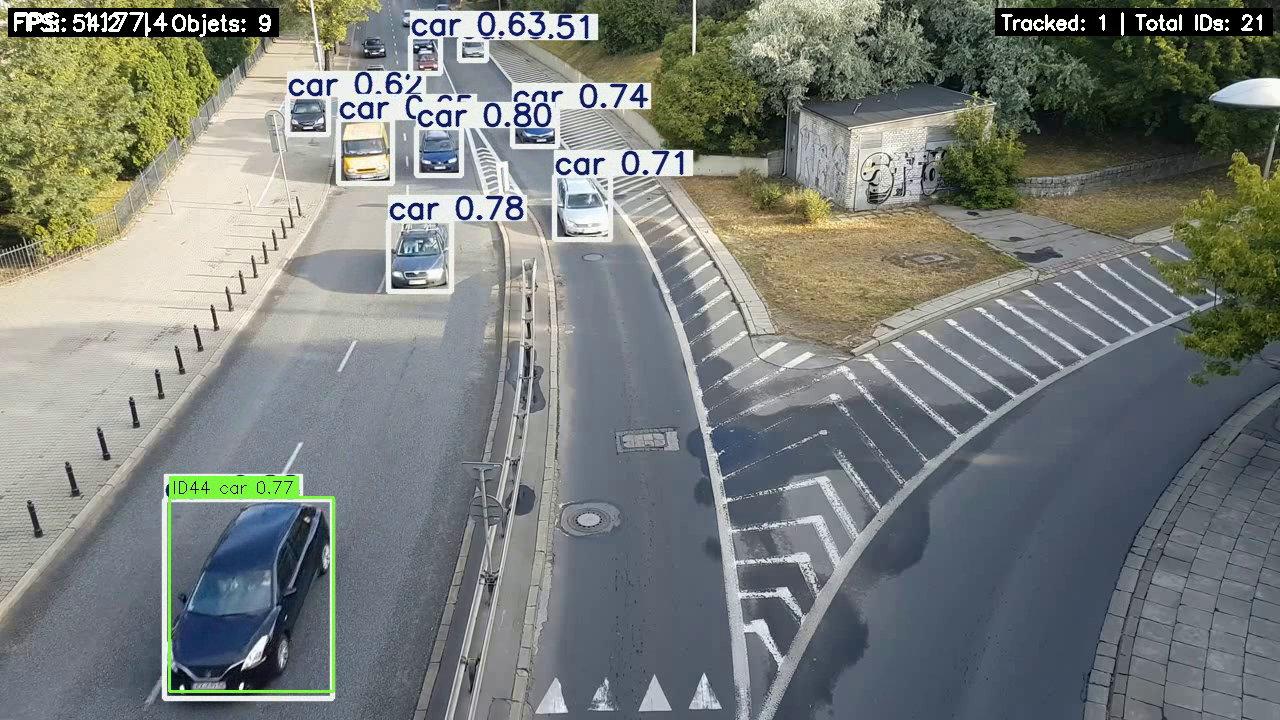

  Frame 450


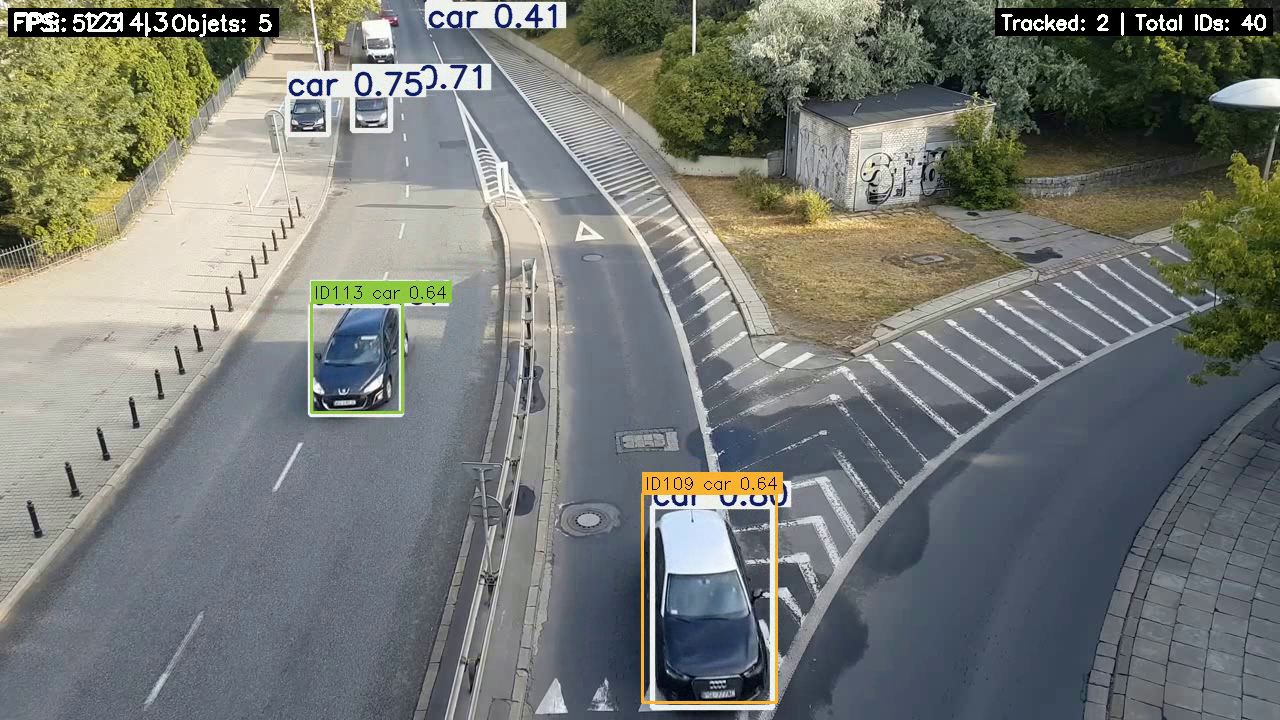

  Frame 675


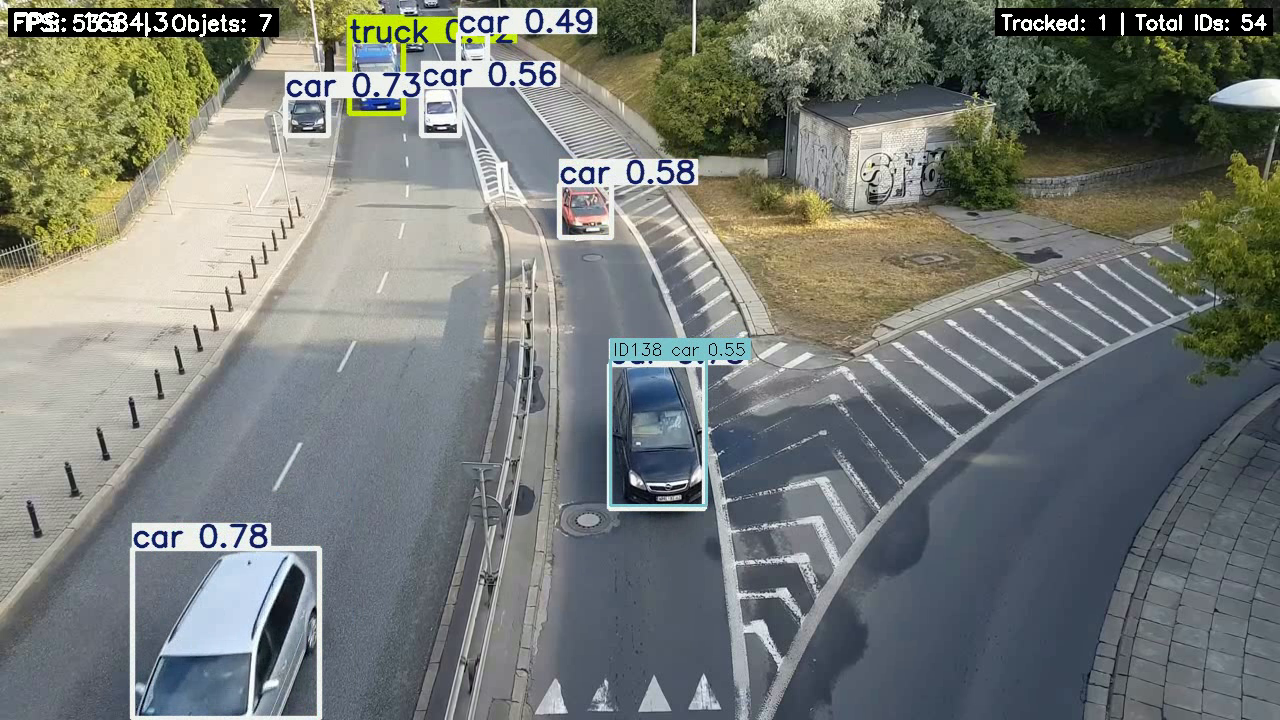

In [5]:
import cv2
from google.colab.patches import cv2_imshow

# Affichage de 3 frames espacées pour vérifier les IDs
cap_v  = cv2.VideoCapture(TRACKING_OUT)
n_out  = int(cap_v.get(cv2.CAP_PROP_FRAME_COUNT))

positions = [n_out // 4, n_out // 2, 3 * n_out // 4]
print('Aperçu du tracking sur 3 frames :')

for pos in positions:
    cap_v.set(cv2.CAP_PROP_POS_FRAMES, pos)
    ret, f = cap_v.read()
    if ret:
        print(f'  Frame {pos}')
        cv2_imshow(f)

cap_v.release()

## Cellule 3 - Statistiques et visualisation des trajectoires

Tableau des objets suivis :
 track_id class_name  frames_visible  first_frame  last_frame  duration_s
      148        car             177          684         900        5.90
      108        car              97          375         543        3.23
        2        car              70            2         101        2.33
      121        car              68          509         606        2.27
       54        car              64          215         299        2.13
      172        car              64          801         893        2.13
       85        car              58          317         379        1.93
       97        car              54          341         402        1.80
      120      truck              52          489         547        1.73
      146        bus              51          664         765        1.70
      138        car              49          617         694        1.63
      109        car              46          380         451        1.53
       52 

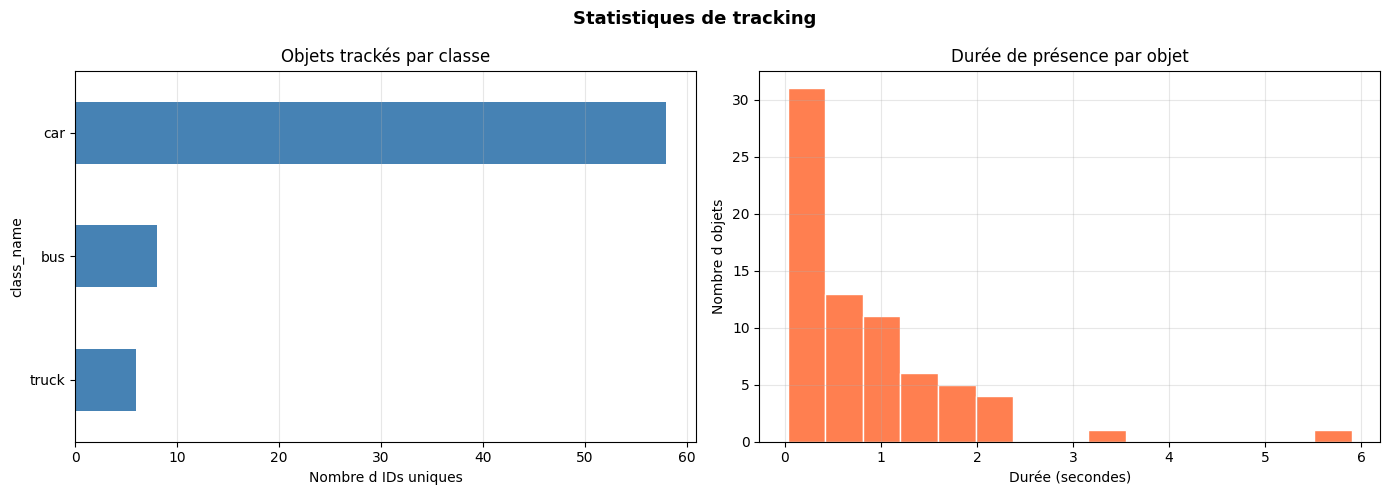

Graphique sauvegardé : outputs/video/tracking_stats_chart.png


In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Résumé des objets trackés
df = pd.DataFrame([
    {
        'track_id':      tid,
        'class_name':    d['class_name'],
        'frames_visible': d['frames'],
        'first_frame':   d['first_frame'],
        'last_frame':    d['last_frame'],
        'duration_s':    round(d['frames'] / fps_s, 2)
    }
    for tid, d in track_data.items()
])

df = df.sort_values('frames_visible', ascending=False).reset_index(drop=True)

print('Tableau des objets suivis :')
print(df.to_string(index=False))
print()

# Graphique : répartition par classe
class_counts = df.groupby('class_name')['track_id'].count().sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Statistiques de tracking', fontsize=13, fontweight='bold')

# Barplot classes
class_counts.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Objets trackés par classe')
axes[0].set_xlabel('Nombre d IDs uniques')
axes[0].grid(True, alpha=0.3, axis='x')

# Distribution durée de présence
axes[1].hist(df['duration_s'], bins=15, color='coral', edgecolor='white')
axes[1].set_title('Durée de présence par objet')
axes[1].set_xlabel('Durée (secondes)')
axes[1].set_ylabel('Nombre d objets')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/video/tracking_stats_chart.png', dpi=100)
plt.show()
print('Graphique sauvegardé : outputs/video/tracking_stats_chart.png')

## Cellule 4 - Discussion sur les erreurs d'association

In [7]:
# Identification des objets avec des durées très courtes
# Ce sont souvent des faux positifs ou des ré-identifications ratées

seuil_frames = int(fps_s * 0.5)  # moins de 0.5 seconde de présence

fragmented = df[df['frames_visible'] < seuil_frames]
stable     = df[df['frames_visible'] >= seuil_frames]

print('ANALYSE DES ERREURS D ASSOCIATION')
print('=' * 45)
print(f'IDs stables (>= 0.5s)     : {len(stable)}')
print(f'IDs fragmentés (< 0.5s)   : {len(fragmented)}')
print(f'Taux de fragmentation      : {len(fragmented)/len(df)*100:.1f}%')
print()
print('SOURCES D ERREURS IDENTIFIEES :')
print()
print('1. Occlusion : quand un objet passe derrière un autre,')
print('   il peut perdre son ID et en recevoir un nouveau à la réapparition.')
print()
print('2. Sortie / entrée de cadre : un objet qui quitte et revient')
print('   dans le champ de vision est traité comme un nouvel objet.')
print()
print('3. Faible confiance de détection : si la détection descend')
print('   sous le seuil sur quelques frames, le tracker perd le fil.')
print()
print('4. Similarité visuelle : ByteTrack utilise IoU (chevauchement')
print('   des bounding boxes) pour associer les IDs.')
print('   Deux objets similaires proches peuvent être confondus.')
print()
print('MITIGATION POSSIBLE :')
print('  - Augmenter le buffer de mémoire du tracker (track_buffer)')
print('  - Utiliser BoT-SORT (apparence + IoU) pour meilleure réidentification')
print('  - Augmenter le seuil de confiance détection (0.4 -> 0.5)')

ANALYSE DES ERREURS D ASSOCIATION
IDs stables (>= 0.5s)     : 37
IDs fragmentés (< 0.5s)   : 35
Taux de fragmentation      : 48.6%

SOURCES D ERREURS IDENTIFIEES :

1. Occlusion : quand un objet passe derrière un autre,
   il peut perdre son ID et en recevoir un nouveau à la réapparition.

2. Sortie / entrée de cadre : un objet qui quitte et revient
   dans le champ de vision est traité comme un nouvel objet.

3. Faible confiance de détection : si la détection descend
   sous le seuil sur quelques frames, le tracker perd le fil.

4. Similarité visuelle : ByteTrack utilise IoU (chevauchement
   des bounding boxes) pour associer les IDs.
   Deux objets similaires proches peuvent être confondus.

MITIGATION POSSIBLE :
  - Augmenter le buffer de mémoire du tracker (track_buffer)
  - Utiliser BoT-SORT (apparence + IoU) pour meilleure réidentification
  - Augmenter le seuil de confiance détection (0.4 -> 0.5)


## Cellule 5 - Export tracking_stats.json (livrable standardisé)

In [8]:
import json
import numpy as np

# Ce fichier est le livrable officiel pour le dashboard de Personne D
# Le format doit correspondre exactement à la fiche de standardisation

cap_info = cv2.VideoCapture(VIDEO_CLIP)
total_f  = int(cap_info.get(cv2.CAP_PROP_FRAME_COUNT))
fps_real = cap_info.get(cv2.CAP_PROP_FPS)
cap_info.release()
duration_s = round(total_f / fps_real, 1) if fps_real > 0 else 0

# Comptage par classe
class_counts_dict = df.groupby('class_name')['track_id'].count().to_dict()

stats = {
    'video_source':          'urban_sample.mp4',
    'total_frames':          int(frame_idx),
    'duration_seconds':      duration_s,
    'fps_average':           round(float(np.mean(fps_values)), 1),
    'unique_objects_tracked': int(len(track_data)),
    'classes_detected':      list(class_counts_dict.keys()),
    'class_counts':          {k: int(v) for k, v in class_counts_dict.items()},
    'track_summary': [
        {
            'track_id':      int(tid),
            'class_name':    d['class_name'],
            'frames_visible': int(d['frames']),
            'first_frame':   int(d['first_frame']),
            'last_frame':    int(d['last_frame'])
        }
        for tid, d in track_data.items()
    ]
}

JSON_OUT = 'outputs/video/tracking_stats.json'
with open(JSON_OUT, 'w', encoding='utf-8') as f:
    json.dump(stats, f, indent=2, ensure_ascii=False)

print('tracking_stats.json généré :')
print(json.dumps(
    {k: v for k, v in stats.items() if k != 'track_summary'},
    indent=2
))
print(f'  track_summary : {len(stats["track_summary"])} entrées')

tracking_stats.json généré :
{
  "video_source": "urban_sample.mp4",
  "total_frames": 901,
  "duration_seconds": 30.0,
  "fps_average": 1297.3,
  "unique_objects_tracked": 72,
  "classes_detected": [
    "bus",
    "car",
    "truck"
  ],
  "class_counts": {
    "bus": 8,
    "car": 58,
    "truck": 6
  }
}
  track_summary : 72 entrées


## Cellule 6 - Sauvegarde Drive et instructions pour le repo

In [9]:
import shutil

# Copie sur Drive
shutil.copy(TRACKING_OUT,  DRIVE_OUTPUT + '/tracking_demo.mp4')
shutil.copy(JSON_OUT,      DRIVE_OUTPUT + '/tracking_stats.json')

print('Fichiers copiés sur Drive :')
print(' ', DRIVE_OUTPUT + '/tracking_demo.mp4')
print(' ', DRIVE_OUTPUT + '/tracking_stats.json')
print()
print('PROCHAINES ETAPES pour le repo GitHub :')
print()
print('1. Télécharger tracking_stats.json depuis Drive')
print('   le placer dans outputs/video/tracking_stats.json')
print()
print('2. Télécharger tracking_demo.mp4 et annotated_video.mp4 depuis Drive')
print('   les partager via le lien Drive dans le README (trop lourds pour Git)')
print()
print('3. Commit et push :')
print('   git add outputs/video/tracking_stats.json notebooks/05_video.ipynb notebooks/06_tracking.ipynb')
print('   git commit -m "feat(C): tracking ByteTrack + stats JSON"')
print('   git push origin feature/personne-C')

Fichiers copiés sur Drive :
  /content/drive/MyDrive/Smart-Urban-Vision-Assets/videos/tracking_demo.mp4
  /content/drive/MyDrive/Smart-Urban-Vision-Assets/videos/tracking_stats.json

PROCHAINES ETAPES pour le repo GitHub :

1. Télécharger tracking_stats.json depuis Drive
   le placer dans outputs/video/tracking_stats.json

2. Télécharger tracking_demo.mp4 et annotated_video.mp4 depuis Drive
   les partager via le lien Drive dans le README (trop lourds pour Git)

3. Commit et push :
   git add outputs/video/tracking_stats.json notebooks/05_video.ipynb notebooks/06_tracking.ipynb
   git commit -m "feat(C): tracking ByteTrack + stats JSON"
   git push origin feature/personne-C
